## Exercise 6

#### AI Declaration
ChatGPT was used to do this exercise 

In [4]:
#importing statements
import numpy as np
import matplotlib.pyplot as plt

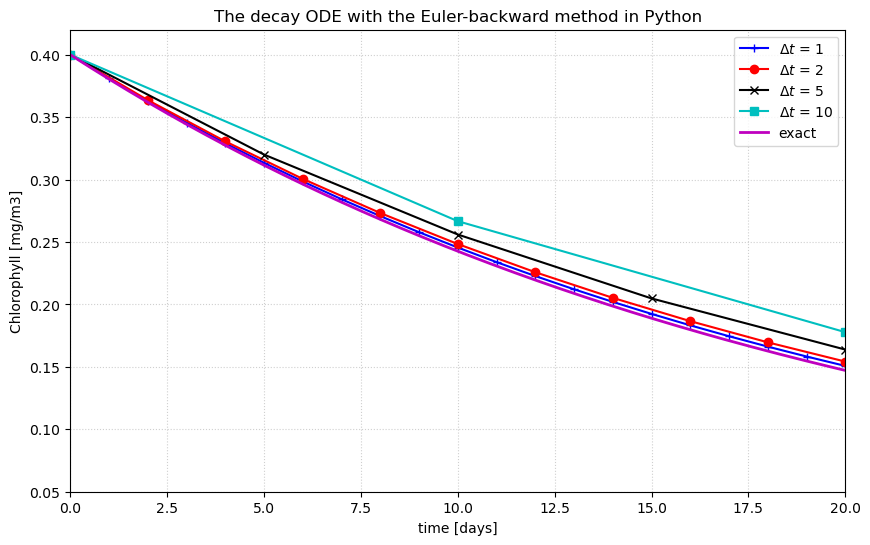

In [3]:
# Fixed parameters
t0 = 0
tn = 20
kappa = 0.05  # day^-1
C0 = 0.4      # mg chl m^-3

# Different time steps to test (matching the original slide)
dt_values = [1, 2, 5, 10]
colors = ['b', 'r', 'k', 'c']
markers = ['+', 'o', 'x', 's']

plt.figure(figsize=(10, 6))

# Loop through each dt value to compute and plot
for idx, dt in enumerate(dt_values):
    # Compute total number of steps
    Ntot = int(np.floor((tn - t0) / dt) + 1)
    
    # Initializations
    C = np.zeros(Ntot)
    t = np.zeros(Ntot)
    t[0] = t0
    C[0] = C0
    
    # Start the Euler-backward loop
    for n in range(0, Ntot - 1):
        t[n+1] = t[n] + dt
        # Euler-backward algebraic update step:
        C[n+1] = C[n] / (1 + kappa * dt)
        
    # Plot current dt result
    plt.plot(t, C, color=colors[idx], linestyle='-', marker=markers[idx], 
             label=f'$\Delta t$ = {dt}')

# Plot Exact Analytical Solution
t_exact = np.linspace(t0, tn, 200)
C_exact = C0 * np.exp(-kappa * t_exact)
plt.plot(t_exact, C_exact, color='m', linestyle='-', linewidth=2, label='exact')

# Formatting the plot to match your slide exactly
plt.xlabel('time [days]')
plt.ylabel('Chlorophyll [mg/m3]')
plt.title('The decay ODE with the Euler-backward method in Python')
plt.xlim(0, tn)
plt.ylim(0.05, 0.42)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

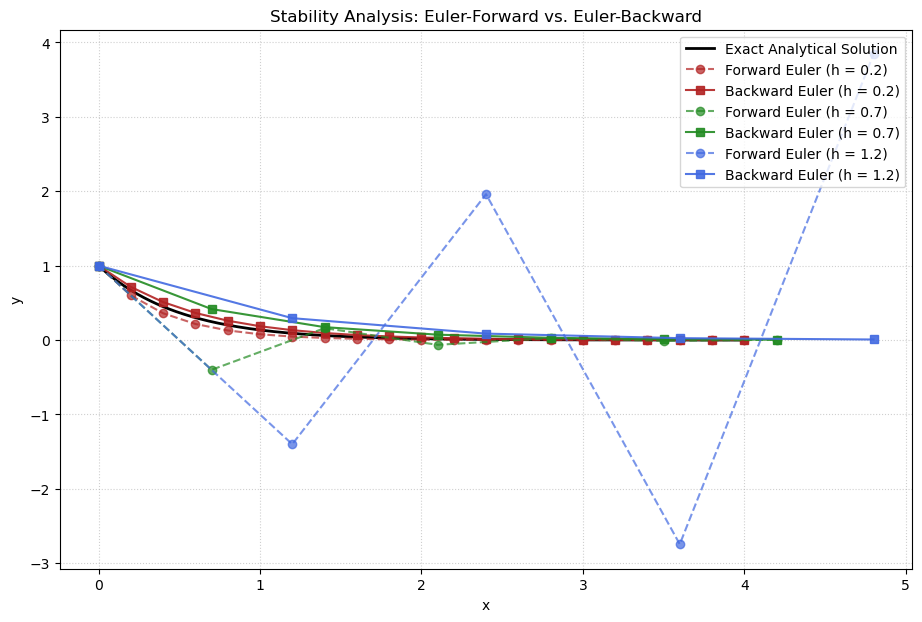

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def f(x, y):
    """The ODE derivative function dy/dx = f(x, y)"""
    return -2.0 * y

def euler_forward(f, x0, y0, x_end, h):
    """Standard Euler-Forward implementation."""
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    
    for n in range(0, len(x) - 1):
        y[n+1] = y[n] + h * f(x[n], y[n])
    return x, y

def euler_backward(f, x0, y0, x_end, h):
    """Modified Euler-Backward implementation using an implicit solver."""
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    
    for n in range(0, len(x) - 1):
        x_next = x[n+1]
        y_curr = y[n]
        
        # We need to solve: y_next - y_curr - h * f(x_next, y_next) = 0
        # fsolve finds the root (y_next) that satisfies this equation
        implicit_eq = lambda y_next: y_next - y_curr - h * f(x_next, y_next)
        
        # Use the current y as an initial guess for the solver
        y[n+1] = fsolve(implicit_eq, y_curr)[0]
        
    return x, y

# Simulation Parameters
x0, y0 = 0.0, 1.0
x_end = 4.0
h_values = [0.2, 0.7, 1.2]  # Test varying step sizes

# Setup Plot
plt.figure(figsize=(11, 7))
x_exact = np.linspace(x0, x_end, 400)
plt.plot(x_exact, y0 * np.exp(-2.0 * x_exact), 'k-', linewidth=2, label='Exact Analytical Solution')

# Run and compare both methods across different h values
colors = ['firebrick', 'forestgreen', 'royalblue']
for i, h in enumerate(h_values):
    # Forward Method
    xf, yf = euler_forward(f, x0, y0, x_end, h)
    plt.plot(xf, yf, color=colors[i], linestyle='--', marker='o', alpha=0.7,
             label=f'Forward Euler (h = {h})')
    
    # Backward Method
    xb, yb = euler_backward(f, x0, y0, x_end, h)
    plt.plot(xb, yb, color=colors[i], linestyle='-', marker='s', alpha=0.9,
             label=f'Backward Euler (h = {h})')

plt.title('Stability Analysis: Euler-Forward vs. Euler-Backward')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.show()